# **Util**

In [7]:
import matplotlib.pyplot as plt
import numpy as np


class util(object):
    @staticmethod
    def add_intercept(x):
        """Add intercept to matrix x.

        Args:
            x: 2D NumPy array.

        Returns:
            New matrix same as x with 1's in the 0th column.
        """
        new_x = np.zeros((x.shape[0], x.shape[1] + 1), dtype=x.dtype)
        new_x[:, 0] = 1
        new_x[:, 1:] = x
        return new_x

    @staticmethod
    def load_dataset(csv_path, label_col='y', add_intercept=False):
        """Load dataset from a CSV file.

        Args:
            csv_path: Path to CSV file containing dataset.
            label_col: Name of column to use as labels (should be 'y' or 't').
            add_intercept: Add an intercept entry to x-values.

        Returns:
            xs: Numpy array of x-values (inputs).
            ys: Numpy array of y-values (labels).
        """
        # Validate label_col argument
        allowed_label_cols = ('y', 't')
        if label_col not in allowed_label_cols:
            raise ValueError(
                f'Invalid label_col: {label_col} (expected one of {allowed_label_cols})'
            )

        # Load headers
        with open(csv_path, 'r') as csv_fh:
            headers = csv_fh.readline().strip().split(',')

        # Load features and labels
        x_cols = [i for i in range(len(headers)) if headers[i].startswith('x')]
        l_cols = [i for i in range(len(headers)) if headers[i] == label_col]
        inputs = np.loadtxt(csv_path, delimiter=',', skiprows=1, usecols=x_cols)
        labels = np.loadtxt(csv_path, delimiter=',', skiprows=1, usecols=l_cols)

        if inputs.ndim == 1:
            inputs = np.expand_dims(inputs, -1)

        if add_intercept:
            inputs = util.add_intercept(inputs)

        return inputs, labels

    @staticmethod
    def plot(x, y, theta, save_path=None, correction=1.0):
        """Plot dataset and fitted logistic regression parameters.

        Args:
            x: Matrix of training examples, one per row.
            y: Vector of labels in {0, 1}.
            theta: Vector of parameters for logistic regression model.
            save_path: Path to save the plot.
            correction: Correction factor to apply (Problem 2(e) only).
        """
        # Plot dataset
        plt.figure()
        plt.plot(x[y == 1, -2], x[y == 1, -1], 'bx', linewidth=2)
        plt.plot(x[y == 0, -2], x[y == 0, -1], 'go', linewidth=2)

        # Plot decision boundary (found by solving for theta^T x = 0)
        margin1 = (max(x[:, -2]) - min(x[:, -2])) * 0.2
        margin2 = (max(x[:, -1]) - min(x[:, -1])) * 0.2
        x1 = np.arange(min(x[:, -2]) - margin1, max(x[:, -2]) + margin1, 0.01)
        x2 = -(theta[0] / theta[2] * correction + theta[1] / theta[2] * x1)
        plt.plot(x1, x2, c='red', linewidth=2)
        plt.xlim(x[:, -2].min() - margin1, x[:, -2].max() + margin1)
        plt.ylim(x[:, -1].min() - margin2, x[:, -1].max() + margin2)

        # Add labels and save to disk
        plt.xlabel('x1')
        plt.ylabel('x2')
        if save_path is not None:
            plt.savefig(save_path)
        plt.show()


# **Base class**

In [8]:
class LinearModel(object):

    def __init__(self, step_size=0.01, max_iter=1000, eps=1e-6,
           theta_0=None, verbose=False):
        self.step_size = step_size
        self.max_iter = max_iter
        self.eps = eps
        self.theta = theta_0
        self.verbose = verbose

    def fit(self, X, y):

        raise NotImplementedError("Sub class of LinearModel must implement fit method.")

    def predict(self, X):

        raise NotImplementedError("Sub class of LinearModel must implement predict method")

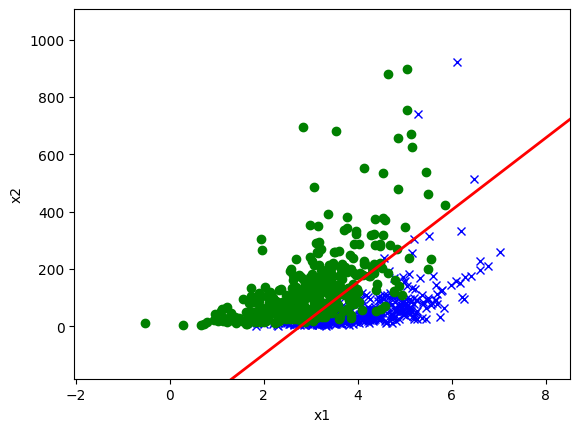

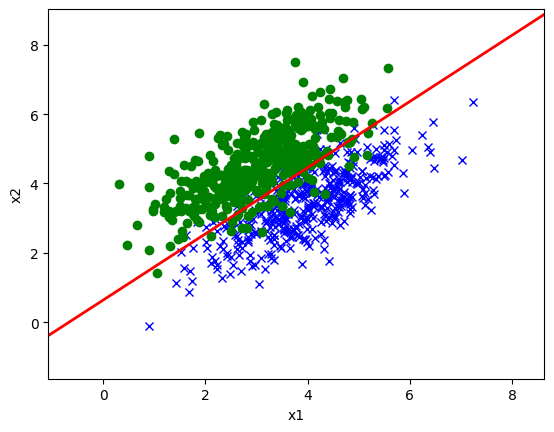

In [25]:
class GDA(LinearModel):


    def fit(self, X, y):

        m, n = X.shape

        self.theta = np.zeros(n + 1)

        # compute phi, mu0, mu1, epsilon
        phi = 1/m * sum(y == 1)
        mu_0 = np.sum(X[y == 0], axis=0) / sum(y == 0)
        mu_1 = np.sum(X[y == 1], axis=0) / sum(y == 1)
        sigma = ((X[y == 0] - mu_0).T @ (X[y == 0] - mu_0) +
                 (X[y == 1] - mu_1).T @ (X[y == 1] - mu_1)) / m

        # Compute theta
        sigma_inv = np.linalg.inv(sigma)

        self.theta[0] = 0.5 * (mu_0.T @ sigma_inv @ mu_0 - mu_1.T @ sigma_inv @ mu_1) - np.log((1 - phi) / phi)
        self.theta[1:] = sigma_inv @ (mu_1 - mu_0)
        
    def predict(self, X):
        return 1 / (1 + np.exp(-X @ self.theta))

def run(train_path, eval_path, pred_path):
    X_train, Y_train = util.load_dataset(train_path, add_intercept = False)

    model = GDA()

    model.fit(X_train, Y_train)

    util.plot(X_train, Y_train, model.theta, "Output/GaussianDiscriminantAnalysis_{}.png".format(train_path[7]))

    X_eval, Y_eval = util.load_dataset(eval_path, add_intercept = True)

    Y_pred = model.predict(X_eval)

    np.savetxt("Output/GaussianDiscriminantAnalysis_{}.txt".format(train_path[7]), Y_pred > 0.5, fmt='%d')

if __name__ == "__main__":
    run(train_path = "Data/ds1_train.csv",
       eval_path = "Data/ds1_valid.csv",
       pred_path = "Output/GaussianDiscriminantAnalysis.txt")
    
    run(train_path = "Data/ds2_train.csv",
       eval_path = "Data/ds2_valid.csv",
       pred_path = "Output/GaussianDiscriminantAnalysis.txt")
    

    